In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt

In [1]:
def process_scenarios(S_data, beta, delta):
    # Step 1: Reorganize data with scenario at the top level
    S_data_by_scenario = defaultdict(lambda: defaultdict(lambda: defaultdict(dict)))
    for antigen, year_data in S_data.items():
        for year, scenario_data in {y: d for y, d in year_data.items() if y != '0'}.items():
            for scenario, value in scenario_data.items():
                S_data_by_scenario[scenario][year][antigen] = value

    # Convert to regular dictionary
    S_data_by_scenario = dict(S_data_by_scenario)

    # Step 2: Scale data
    S_data_by_scenario_scaled = defaultdict(lambda: defaultdict(lambda: defaultdict(dict)))
    for scenario, years in S_data_by_scenario.items():
        for year, antigens in years.items():
            for antigen in antigens.keys():
                S_data_by_scenario_scaled[scenario][year][antigen] = (
                    S_data_by_scenario[scenario][year][antigen]
                )

    # Step 3: Calculate scenario sums
    scenario_sums = {}
    for scenario, years in S_data_by_scenario_scaled.items():
        scenario_sum = sum(
            value
            for year in years.values()
            for value in year.values()
            if isinstance(value, (int, float))
        )
        scenario_sums[scenario] = scenario_sum

    return scenario_sums

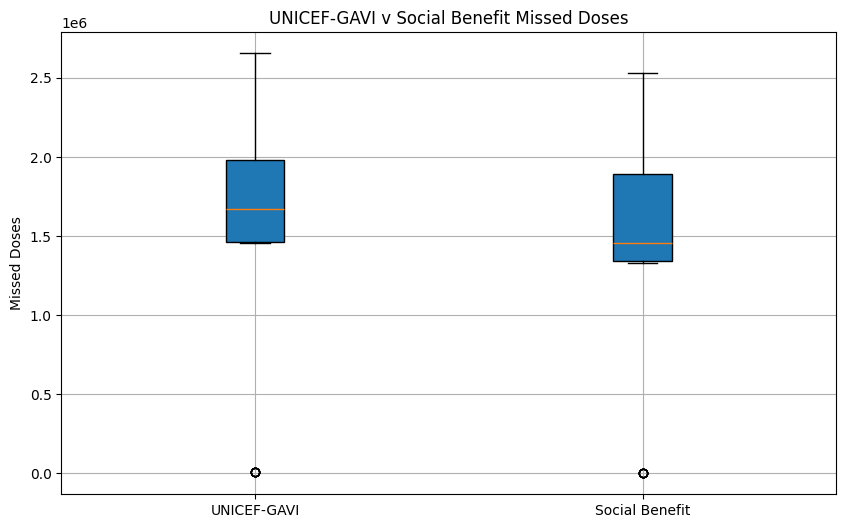

In [8]:


# Combine both datasets into a DataFrame for plotting
combined_data = pd.DataFrame({
    'Scenario': aggregated_by_scenario_df['Scenario'],
    'Dataset 1': aggregated_by_scenario_df['Total_Unvaccinated'],
    'Dataset 2': aggregated_second_dataset.values()
})

# Create a double box plot for the two datasets
plt.figure(figsize=(10, 6))
plt.boxplot([combined_data['Dataset 1'], combined_data['Dataset 2']], labels=['UNICEF-GAVI', 'Social Benefit'], patch_artist=True)
plt.title('UNICEF-GAVI v Social Benefit Missed Doses')
plt.ylabel('Missed Doses')
plt.grid(True)
plt.savefig('UG_V_SB_missed_doses.pdf', bbox_inches='tight', pad_inches=0.1, dpi=600)
plt.show()
